In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

In [2]:
df = pd.read_csv(
    'https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data',
    names=['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'accep']
)
df['accep'] = ~(df['accep'] == 'unacc')

In [3]:
X = pd.get_dummies(df.iloc[:, 0:6])
y = df['accep']

print("First 5 rows:\n", df.head())
print("Feature columns:", X.columns.tolist())
print("Number of features:", len(X.columns))

First 5 rows:
   buying  maint doors persons lug_boot safety  accep
0  vhigh  vhigh     2       2    small    low  False
1  vhigh  vhigh     2       2    small    med  False
2  vhigh  vhigh     2       2    small   high  False
3  vhigh  vhigh     2       2      med    low  False
4  vhigh  vhigh     2       2      med    med  False
Feature columns: ['buying_high', 'buying_low', 'buying_med', 'buying_vhigh', 'maint_high', 'maint_low', 'maint_med', 'maint_vhigh', 'doors_2', 'doors_3', 'doors_4', 'doors_5more', 'persons_2', 'persons_4', 'persons_more', 'lug_boot_big', 'lug_boot_med', 'lug_boot_small', 'safety_high', 'safety_low', 'safety_med']
Number of features: 21


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)
dt = DecisionTreeClassifier(
    max_depth=3,      
    ccp_alpha=0.01,    
    criterion='gini'   
)
dt.fit(x_train, y_train)

DecisionTreeClassifier(ccp_alpha=0.01, max_depth=3)

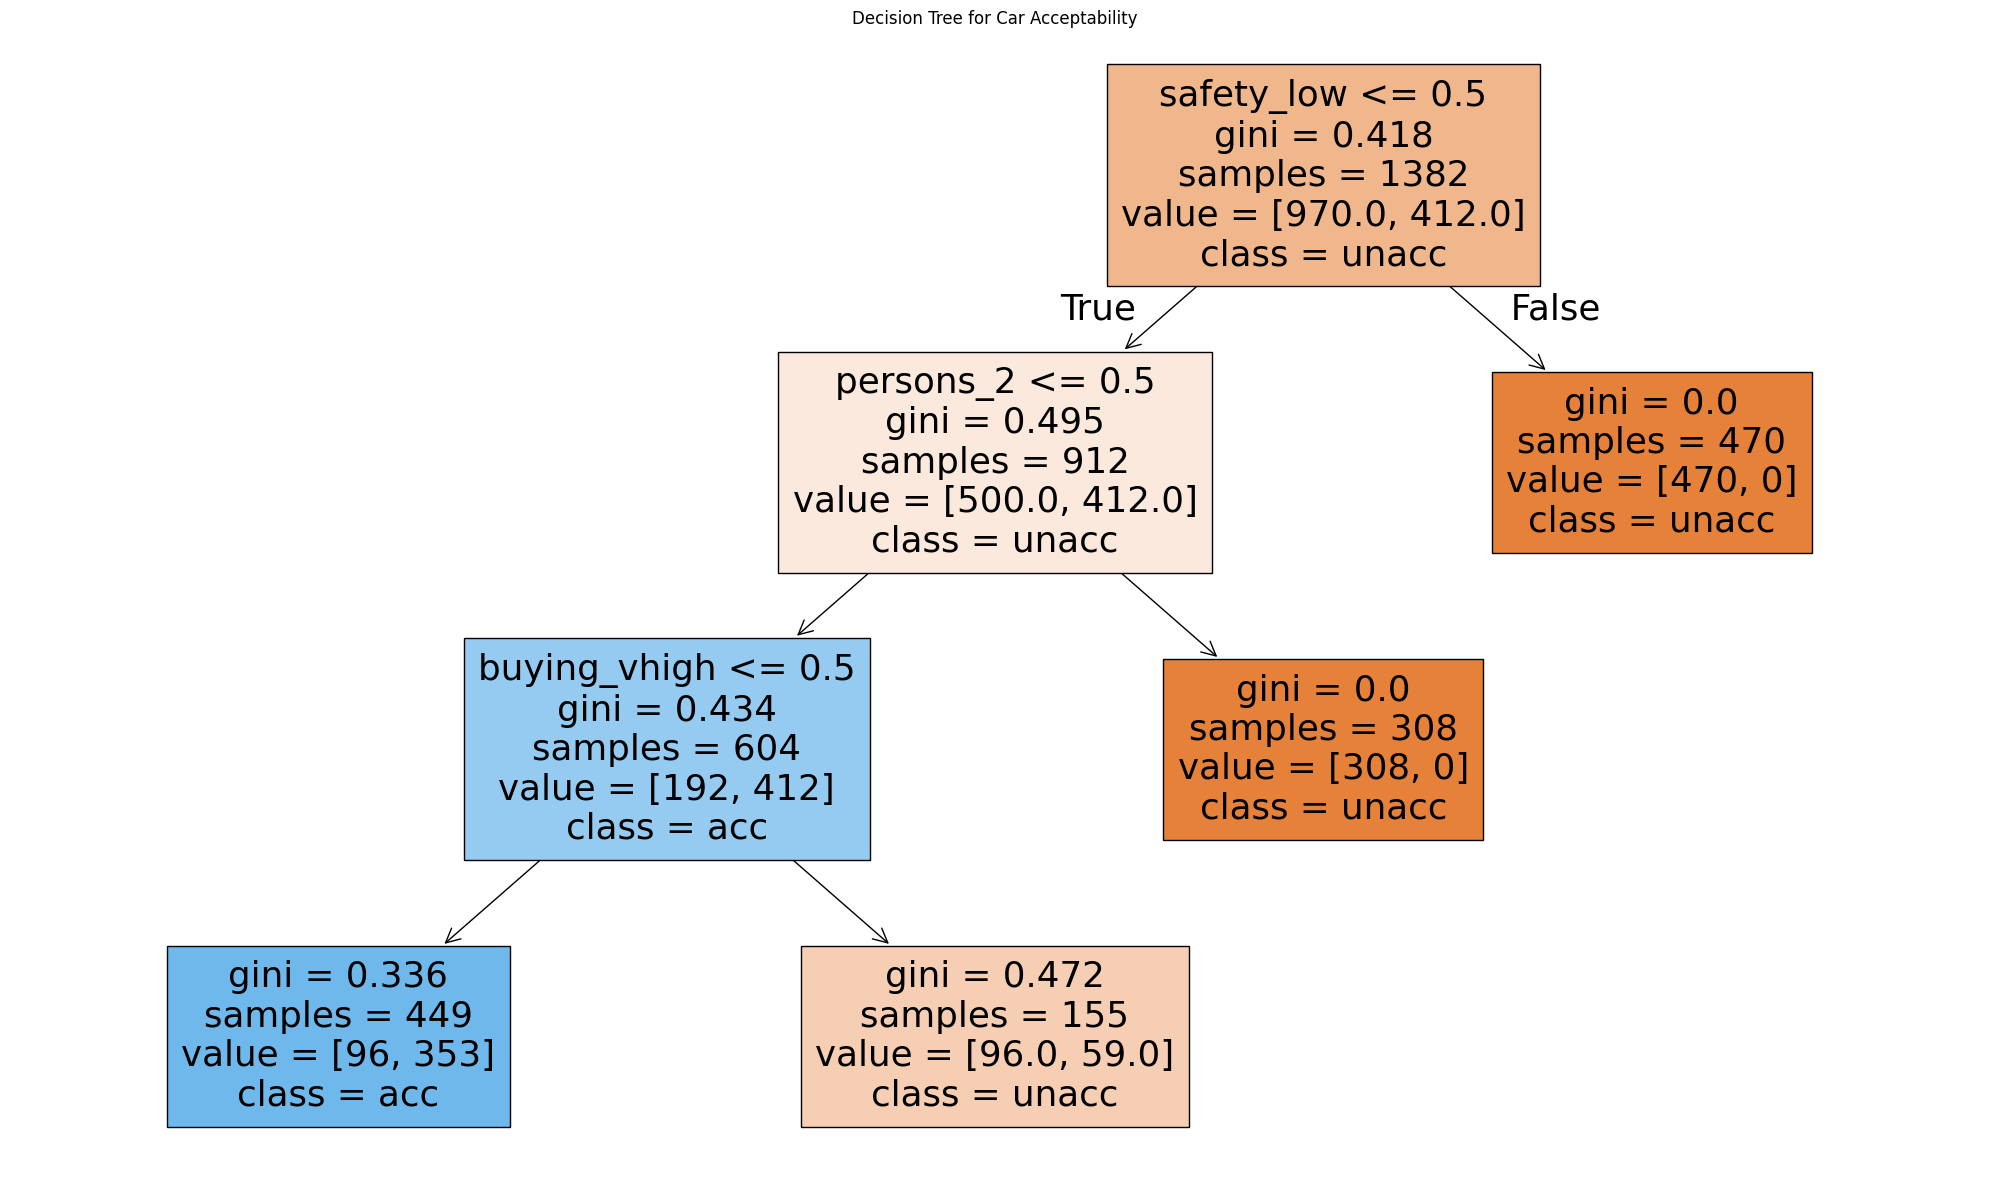

In [5]:
plt.figure(figsize=(20, 12))
tree.plot_tree(
    dt,
    feature_names=x_train.columns,
    class_names=['unacc', 'acc'],
    label='all',
    filled=True
)
plt.title("Decision Tree for Car Acceptability")
plt.tight_layout()
plt.show()


In [6]:
# Helper functions for Gini and Info Gain
def gini(data):
    """Calculate Gini impurity of a dataset"""
    data = pd.Series(data)
    return 1 - sum(data.value_counts(normalize=True) ** 2)

def info_gain(left, right, current_impurity):
    """Information Gain from splitting into left/right branches"""
    w = float(len(left)) / (len(left) + len(right))
    return current_impurity - w * gini(left) - (1 - w) * gini(right)

In [7]:
gi_root = gini(y_train)
print(f"Gini impurity at root: {gi_root:.4f}")

# Example: compute info gain for each feature
info_gain_list = []
for feature in x_train.columns:
    left = y_train[x_train[feature] == 0]
    right = y_train[x_train[feature] == 1]
    gain = info_gain(left, right, gi_root)
    info_gain_list.append([feature, gain])

info_gain_table = pd.DataFrame(info_gain_list, columns=['Feature', 'InfoGain'])
info_gain_table = info_gain_table.sort_values('InfoGain', ascending=False)

print("Top feature split by Information Gain:")
print(info_gain_table.head())

Gini impurity at root: 0.4185
Top feature split by Information Gain:
         Feature  InfoGain
19    safety_low  0.091603
12     persons_2  0.090135
18   safety_high  0.045116
14  persons_more  0.025261
13     persons_4  0.020254
